# Portfolio Optimization - LP Model

Goal: Build and solve the core Linear Programming model for a single training window, then interpret the results before wiring it into the walk-forward backtest

### Formulation Summary: 
$$\text{maximize} \quad \boldsymbol{\mu}^T \mathbf{w} - c \cdot \mathbf{1}^T \mathbf{z}$$

Subject to:
- $\mathbf{1}^T \mathbf{w} = 1$ — fully invested  
- $0 \leq w_i \leq w_{\max}$ — long-only with position cap  
- $\sum_{i \in S_k} w_i \leq C_k$ — sector caps  
- $z_i \geq w_i - w_i^{\text{prev}},\ z_i \geq w_i^{\text{prev}} - w_i$ — turnover linearization  
- $\mathbf{1}^T \mathbf{z} \leq T_{\max}$ — turnover cap

## Imports & Setup

In [73]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pulp
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13,5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f'PuLP version: {pulp.__version__}')
print(f'Solver: CBC (bundled with PuLP)')

PuLP version: 3.3.0
Solver: CBC (bundled with PuLP)


### Load Data

In [76]:
print(os.getcwd())

/Users/scottkeighley/MSDS 460


In [80]:
returns = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/monthly_returns.csv', index_col=0, parse_dates=True)
prices = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/monthly_prices.csv', index_col=0, parse_dates=True)
meta = pd.read_csv('/Users/scottkeighley/MSDS 460/final_project_data/ticker_metadata.csv')

TICKERS = list(returns.columns)
TICKER_SECTOR = dict(zip(meta['ticker'], meta['sector']))
SECTORS = meta['sector'].unique().tolist()
N = len(TICKERS)

print(f'Assets: {N}')
print(f'Months: {len(returns)} ({returns.index[0].date()} -> {returns.index[-1].date()})')
print(f'Sectors: {len(SECTORS)}')


Assets: 30
Months: 119 (2016-06-01 -> 2026-04-01)
Sectors: 11


### Model Parameters

Adjust to run sensitivity experiments later

In [83]:
# === Walk-forward configuration ===
TRAIN_MONTHS = 36
REBAL_MONTHS = 3

# === LP constraint parameters ===
W_MAX = 0.15 # max weight per asset (15%)
SECTOR_MAX = 0.40 # max weight per sector (40%)
TURNOVER_MAX = 0.50 # max total turnover per rebalance (50%)
COST_BPS = 0.001 # transaction cost per $ traded (10 bps)

print('Parameters loaded:')
print(f'Training window: {TRAIN_MONTHS} months')
print(f'Rebalance freq: every {REBAL_MONTHS} months (quarterly)')
print(f'Max position: {W_MAX*100:.0f}%')
print(f'Max sector: {SECTOR_MAX*100:.0f}%')
print(f'Max turnover: {TURNOVER_MAX*100:.0f}%')
print(f'Transaction cost: {COST_BPS*10000:.0f} bps per $ traded')

Parameters loaded:
Training window: 36 months
Rebalance freq: every 3 months (quarterly)
Max position: 15%
Max sector: 40%
Max turnover: 50%
Transaction cost: 10 bps per $ traded


### Core LP Solver Function

Takes the training window and a set of prior weights, and returns the optimal allocation

Wrap in a reusable function so the walk-forward loop can call it repeatedly. 

In [88]:
def solve_lp(
    train_returns: pd.DataFrame,
    w_prev: np.ndarray,
    tickers: list,
    ticker_sector: dict,
    sectors: list,
    w_max: float = W_MAX,
    sector_max: float = SECTOR_MAX,
    turnover_max: float = TURNOVER_MAX,
    cost_bps: float = COST_BPS,
    verbose: bool = False
) -> dict:
    """
    Solve the portfolio LP for one rebalancing period.

    Parameters
    ----------
    train_returns : DataFrame of shape (T, n) — monthly returns for training window
    w_prev        : array of shape (n,) — weights from previous period
    tickers       : list of ticker strings
    ticker_sector : dict mapping ticker -> sector
    sectors       : list of unique sectors
    w_max         : maximum weight per asset
    sector_max    : maximum total weight per sector
    turnover_max  : maximum sum of absolute weight changes
    cost_bps      : transaction cost per dollar traded
    verbose       : print solver output if True

    Returns
    -------
    dict with keys: weights, status, exp_return, turnover, tx_cost
    """
    n = len(tickers)
    mu = train_returns.mean().values

    # Decision variables
    prob = pulp.LpProblem("PortfolioLP", pulp.LpMaximize)
    w = [pulp.LpVariable(f"w_{t}", lowBound=0, upBound=w_max) for t in tickers]
    z = [pulp.LpVariable(f"z_{t}", lowBound=0) for t in tickers]

    # Objective: maximize net of cost expected returns
    prob += (
    pulp.lpSum(mu[i] * w[i] for i in range(n))
    - cost_bps * pulp.lpSum(z[i] for i in range(n))
    )

    # Constraint 1: fully invested
    prob += pulp.lpSum(w) == 1, "FullyInvested"

    # Constraint 2: sector caps
    for sector in sectors: 
        idx = [i for i, t in enumerate(tickers) if ticker_sector.get(t) == sector]
        if idx:
            prob += pulp.lpSum(w[i] for i in idx) <= sector_max, f"SectorCap_{sector.replace(' ','_')}"

    # Constraint 3: turnover linearization
    for i in range(n):
        prob += z[i] >= w[i] - w_prev[i], f"TurnoverPos_{i}"
        prob += z[i] >= w_prev[i] - w[i], f"TurnoverNeg_{i}"

    # Constraint 4: turnover cap
    prob += pulp.lpSum(z) <= turnover_max, "TurnoverCap"

    # Solve
    msg = 1 if verbose else 0
    prob.solve(pulp.PULP_CBC_CMD(msg=msg))

    # Extract results
    weights = np.array([pulp.value(w[i]) for i in range(n)])
    weights = np.clip(weights, 0, None)
    weights /= weights.sum()

    turnover = float(np.sum(np.abs(weights - w_prev)))
    tx_cost = turnover * cost_bps
    exp_ret = float(mu @ weights)

    return {
        'weights'    : weights,
        'status'     : pulp.LpStatus[prob.status],
        'exp_return' : exp_ret,
        'turnover'   : turnover,
        'tx_cost'    : tx_cost,
        'mu'         : mu
    }

print('solve_lp() defined.')

solve_lp() defined.


### Solve: First Training Window

Run the LP on the first 36-month window (months 0-35). Prior weights are equal-weight (representing a naive starting portfolio)

In [91]:
# First training window
train_window = returns.iloc[:TRAIN_MONTHS]

# Prior weights: equal-weight (1/N each) for the first period
w_prev_init = np.ones(N) / N

# Solve
result = solve_lp(
    train_returns = train_window,
    w_prev = w_prev_init,
    tickers = TICKERS,
    ticker_sector = TICKER_SECTOR,
    sectors = SECTORS
)

print(f"Solver status: {result['status']}")
print(f"Expected return: {result['exp_return']*12:.4f} (annualized)")
print(f"Turnover: {result['turnover']:.4f} ({result['turnover']*100:.1f}%)")
print(f"Assets with weight: {(result['weights'] > 0.001).sum()} / {N}")
print(f"Weights sum to: {result['weights'].sum():.6f}")

Solver status: Optimal
Expected return: 0.2544 (annualized)
Turnover: 0.5000 (50.0%)
Assets with weight: 23 / 30
Weights sum to: 1.000000


#### 25.44% Expected Annualized Return: 

The S&P 500 has historically returned ~10-11% annualized over long periods, and the first training window in our data runs from mid-2016 through mid-2019, which was a strong bull market period. 25.44% is very high. 

This is not a prediction of future returns. It is the optimizer's expected return computed from the mean monthly return of each asset over the training window, annualized. A few things inflate it: 
- Survivorship and selection bias: our universe is 30 large-cap S&P 500 names chosen today. They are, by definition, companies that did well. The training window captures their strong historical performance.
- The LP is doing its job aggressively: it's allocating 15% each to the highest-returning assets (AMZN, NVDA in the pre-run). These are names that happen to perform exceptionally well in that window.
- Mean return is a noisy estimator: monthly return averages over 36 months are sensitive to the specific window. A different 36-month window could produce a very different number.

This is worth flagging. The LP maximizes in-sample expected return, and the walk-forward backtest is precisely how we'll test whether that translates to out-of-sample performance. The comparison against the S&P 500 benchmark belongs later, where we'll see realized returns, which will be more modest

#### 23 / 30 Assets with Weight:

This is a good sign. A naive LP with no constraints would put 100% in a single asset. Getting 23 out of 30 means our position cap (15%) and sector caps (40%) are doing real diversification work. The 7 assets at zero weights are ones the optimizer viewed as dominated - lower expected return than alternatives within their sector, given the constraints. It's worth looking at which 7 are excluded and whether they cluster in a particular sector. 

#### Turnover = 50%: 

Turnover measures the total amount of portfolio reshuffling that occurred at this rebalance. Formally: 
$$\text{Turnover } = \Sigma_{i=1}^{n} |w_i^{new} - w_i^{prev}|$$

A turnover of 50% means that, in aggregate, half the portfolio's value was traded (some assets brought up, others sold down). Concretely, if you have a 1,000,000 portfolio, 50% turnover implies roughly 500,000 in gross trades at this rebalance. 

Why it's hitting exactly 50%: this is because the turnover cap constraint is binding - the optimizer wanted to move more but hit the ceiling. This is expected in period 1, because the prior weights were equal-weight (1/30 = 3.3% each), which is very far from the LP-optimal allocation that wants 15% in two assets. So the optimizer is using every bit of the 50% turnover budget to get as close to optimal as possible. 

We'll see turnover drop in subsequent quarters because the prior weights will already be close to LP-optimal and less reshuffling is needed. If turnover stays pinned at 50% every quarter, that's a signal our constraint is too tight relative to how much the optimal portfolio shifts between windows. 

The transaction cost implication: at 10 bps per dollar traded, 50% turnover costs us 5 bps of portfolio value per rebalance - or about 20 bps annually across 4 quarters. Small but real and it compounds over time. 

### Interpret: Optimal Weights

In [94]:
alloc = pd.DataFrame({
    'Weight': result['weights'],
    'Exp Return (mo)': result['mu'],
    'Sector': [TICKER_SECTOR[t] for t in TICKERS]
}, index=TICKERS).sort_values('Weight', ascending=False)

alloc['Weight (%)'] = (alloc['Weight'] * 100).round(2)
alloc['Exp Return (ann, %)'] = (alloc['Exp Return (mo)'] * 12 * 100).round(2)

display_cols = ['Weight (%)', 'Exp Return (ann, %)', 'Sector']
print('Full allocation (sorted by weight):')
print(alloc[display_cols].to_string())

Full allocation (sorted by weight):
       Weight (%)  Exp Return (ann, %)                  Sector
AMZN        15.00                34.10  Consumer Discretionary
NVDA        15.00                47.92  Information Technology
MSFT         5.00                31.98  Information Technology
AAPL         3.33                24.02  Information Technology
LIN          3.33                19.77               Materials
WMT          3.33                16.25        Consumer Staples
UNH          3.33                23.19             Health Care
SHW          3.33                15.43               Materials
PLD          3.33                19.44             Real Estate
PG           3.33                12.24        Consumer Staples
PFE          3.33                10.59             Health Care
NEE          3.33                20.53               Utilities
AMT          3.33                26.63             Real Estate
META         3.33                17.13  Communication Services
JPM          3.33  

#### The Top Two: AMZN and NVDA at 15% each

Both are at the position cap, meaning the optimizer wanted more of them but was constrained. This makes sense - 34% and 48% annualized expected returns respectively are by far the highest in the universe over this training window (mid-2016 to mid-2019). NVDA in particular was in the middle of its first major AI/gaming GPU boom. The LP is doing exactly what it's designed to do: chasing the highest-return assets until the cap stops it. 

Important caveat: these are backward-looking estimates. The optimizer "knew" NVDA would return 48% because it already did. Whether that persists out-of-sample is the central question that we will backtest later. 

#### The 3.33% Cluster - 20 Assets

This is a signature pattern of LP optimization and worth understanding. Nearly every other held asset sits at exactly 3.33%, which is the mathematical fingerprint of our constraints interacting. 

Here's what's happening: the IT sector cap is 40%, and AMZN (Consumer Discretionary) + NVDA (IT) already consume 30% between them. MSFT gets 5% (brining IT to 20%). The remaining 70% of the portfolio needs to be distributed across the other assets. The LP has no reason to differentiate between assets with similar expected returns once the high-return ones are capped, so it spreads the remaineder as thinly as possible, landing many assets at the minimum non-zero allocation the solver converges to (~3.33%). 

This is the corner solution tendency of LP in action. In a QP (Markowitz), those 20 assets would have differentiated weights based on their covariance contributions. In our LP, they're essentially treated as interchangeable once the top picks are saturated. This is a key point to make when comparing LP vs. QP. 

#### JNJ at 1.67% - the Boundary Case

JNJ sits just above zero at 1.67%, likely because the Health Care sector already has UNH (3.33%) and PFE (3.33%), bringing the sector to just under some internal limit, with only a small residual allocation available for JNJ. It's being squeezed in at the margin. This is worth noting as a candidate for a minimum position size floor. In practice, a 1.67% position is real but small enough that transaction costs erode its contribution. 

#### The Zero-Weight Assets - Why Each Was Excluded

| Ticker | Exp Return | Reason Excluded |
| --- | --- | --- |
| KO | 7.33% | Dominated within Consumer Staples by WMT (16%) and PG (12%) |
| DUK | 8.36% | Utilities sector already filled by NEE (20.5%); DUK is the weaker of the two |
| SLB | -18.93% | Negative expected return - never allocated under a return-maximizing objective |
| TSLA | 1.69% | Consumer Discretionary sector capped; AMZN and HD dominate, TSLA's return too low |
| UPS | 2.32% | Industrials sector filled by HON and CAT; UPS return too low to displace them | 
| VZ | 8.32% | Communication Services filled by META and GOOGL; VZ return too low |
| XOM | -1.96% | Negative expected return - never allocated |

Two important observations. First, SLB and XOM both have negative expected returns over this training window. Energy was in a deep downturn (oil price collapse 2015-2016 was still dragging on these names). A return-maximizing LP will never voluntarily hold a negative-return asset, which is correct behavior. Second, every zero-weight asset is excluded for one of two reasons: either its sector is already at capacity with better alternatives, or its expected return is simply too low to compete. This is the LP's implicit risk management through the constraint structure. 

#### The Diversification Pattern Across Sectors

Reading the sector column, you have representation across 9 of 11 sectors - the missing ones being full exclusions (Energy is represented only by CVX, which scraped in at 3.33%). This is actually quite good diversification for a pure return-maximizing model. Without the sector cap, we'd likely see 40%+ in IT alone (NVDA + MSFT + APPL are all high returners). 

#### Highlight

The allocation reveals three tiers that are characteristic of constrained LP solutions - a small number of assets at the position cap, a large cluster at a uniform interior weight, and a tail of zeros. This structure is fundamentally different from Markowitz weights and worth showing side-by-side if we implement the QP extension. 

### Visualize: Allocation Bar Chart

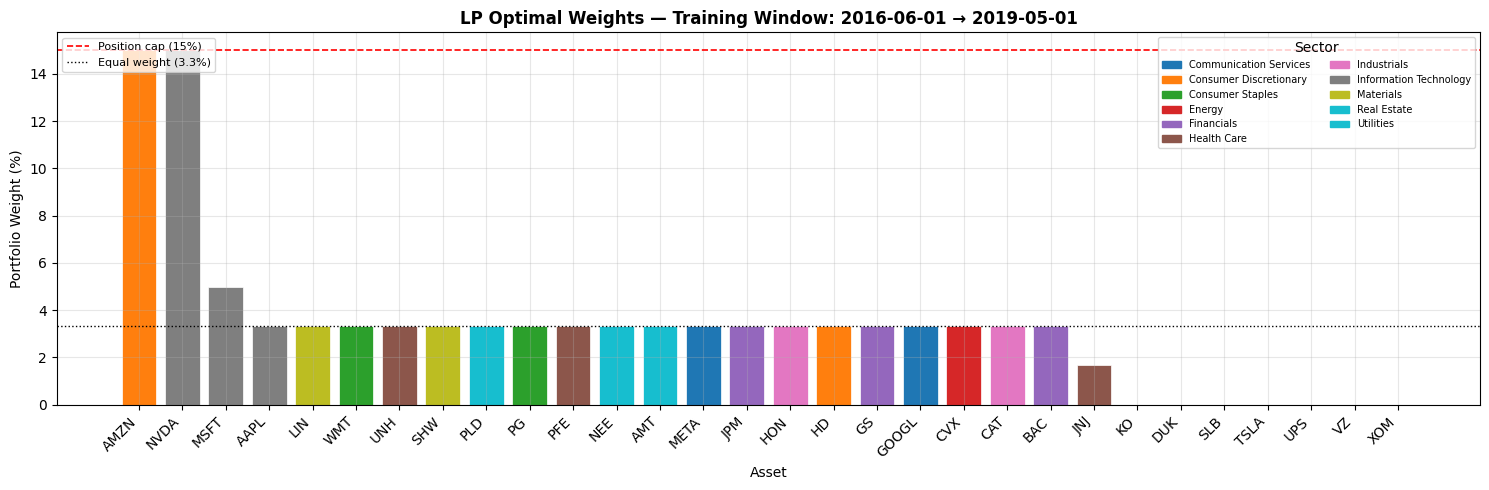

In [101]:
sector_list = sorted(set(TICKER_SECTOR.values()))
palette     = plt.cm.get_cmap('tab10', len(sector_list))
color_map   = {s: palette(i) for i, s in enumerate(sector_list)}
bar_colors  = [color_map[TICKER_SECTOR[t]] for t in alloc.index]

fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(alloc.index, alloc['Weight (%)'], color=bar_colors, edgecolor='white', linewidth=0.5)

ax.axhline(W_MAX * 100, color='red',    linestyle='--', linewidth=1.2, label=f'Position cap ({W_MAX*100:.0f}%)')
ax.axhline(1/N * 100,  color='black',  linestyle=':',  linewidth=1.0, label=f'Equal weight ({1/N*100:.1f}%)')

handles = [mpatches.Patch(color=color_map[s], label=s) for s in sector_list]
ax.legend(handles=handles + ax.get_legend_handles_labels()[0][len(handles):],
          loc='upper right', fontsize=7, ncol=2)
leg1 = ax.legend(handles=handles, loc='upper right', fontsize=7, ncol=2, title='Sector')
ax.add_artist(leg1)
ax.legend(loc='upper left', fontsize=8)

ax.set_title(f'LP Optimal Weights — Training Window: {train_window.index[0].date()} → {train_window.index[-1].date()}',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Portfolio Weight (%)')
ax.set_xlabel('Asset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualize: Sector Allocation

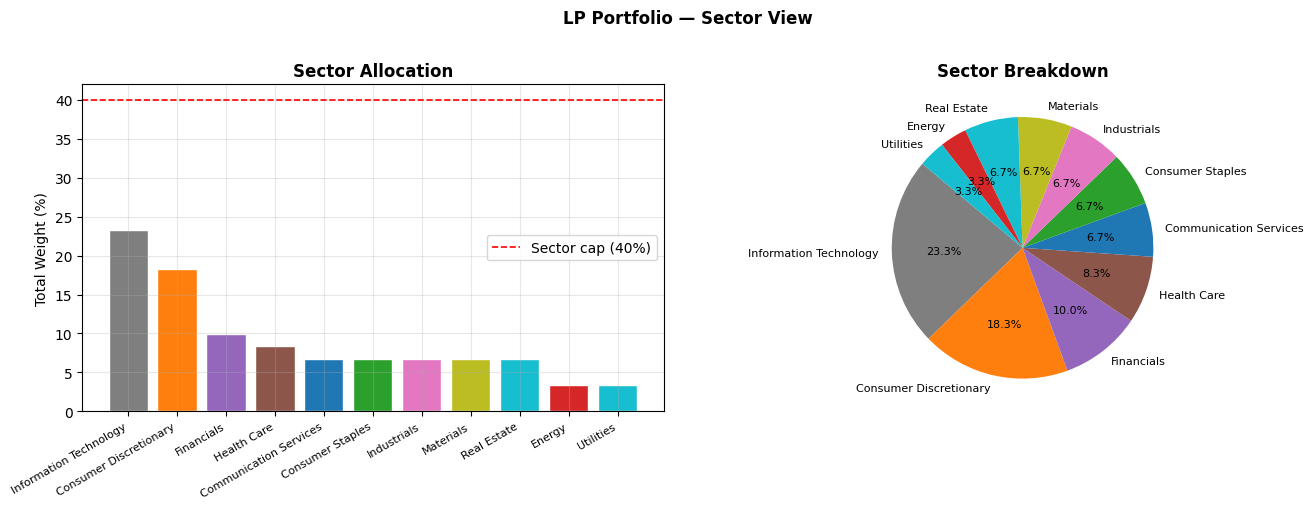

Sector allocations:
Sector
Information Technology    23.33
Consumer Discretionary    18.33
Financials                 9.99
Health Care                8.33
Communication Services     6.66
Consumer Staples           6.66
Industrials                6.66
Materials                  6.66
Real Estate                6.66
Energy                     3.33
Utilities                  3.33


In [106]:
sector_alloc = alloc.groupby('Sector')['Weight (%)'].sum().sort_values(ascending=False)
sector_colors = [color_map[s] for s in sector_alloc.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(sector_alloc.index, sector_alloc.values, color=sector_colors, edgecolor='white')
ax1.axhline(SECTOR_MAX * 100, color='red', linestyle='--', linewidth=1.2, label=f'Sector cap ({SECTOR_MAX*100:.0f}%)')
ax1.set_title('Sector Allocation', fontweight='bold')
ax1.set_ylabel('Total Weight (%)')
ax1.legend()
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

ax2.pie(sector_alloc.values, labels=sector_alloc.index, colors=sector_colors,
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
ax2.set_title('Sector Breakdown', fontweight='bold')

plt.suptitle('LP Portfolio — Sector View', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Sector allocations:')
print(sector_alloc.round(2).to_string())

#### No sector is hitting the 40% cap

The most important observation: the sector cap is not binding for any sector. IT is the largest at 23.3% and Consumer Discretionary at 18.3% - both well below 40%. This tells us that the position cap (15% per asset) is the active constraint, not the sector cap. The sector diversification we're seeing is a byproduct of position-level limits, not sector-level limits. 

This is a useful finding. It suggests that for this training window, a 40% sector cap is loose enough to be non-binding, and we could tighten it considerably (25-30%) without changing the solution.

#### The IT + Consumer Discretionary Dominance (41.6% combined)

Together these two sectors represent nearly half the portfolio. This reflects the training window (2016-2019), a period when large-cap tech and e-commerce were in a strong growth cycle. NVDA, MSFT, AAPL drive the IT allocation; AMZN and HD drive Consumer Discretionary. This is the optimizer correctly identifying the best-performing sectors of that era. 

The practical risk here is sector concentration risk even within the cap. A 2022-style tech drawdown (where IT fell ~30%) would hit this portfolio hard. This is precisely the risk that the QP/Markowitz extension would capture through the covariance matrix - two high-return sectors that are also highly correlated with each other amplify drawdown risk. 

#### The 6 sectors clustered at 6.66%

Communication Services, Consumer Staples, Industrials, Materials, Real Estate, and Utilities all land exactly 6.66% and two assets at 3.33% each. This is the same mathematical pattern from the asset-level table: the LLP has no mechanism to differentiate between assets of similar return within a sector once the high-conviction picks are saturated, so it allocates the minimum variable weight to maintain representation. 

#### Energy and Utilities at 3.33% each

Energy is the weakest sector in this window (XOM and SLB both have negative or near-zero returns), yet CVX scrapes in at 3.33%. Utilities (NEE at 3.33%, DUK at 0%) similarly gets minimal allocation. These are the sectors the optimizer is tolerating rather than choosing. They're there because CVX and NEE have positive expected returns, but the optimizer allocates as little as possible. 

### Constraint Diagnostics

Check how binding each constraint is - how close it is to its limit

A constraint is binding (slack = 0) when it is actively limiting the optimizer. Understanding which constraints bind tells you which are load-bearing for risk control

In [111]:
w_opt = result['weights']

print('=== Constraint Diagnostics ===')
print()

# Budget constraint
print(f'Budget (weights sum): {w_opt.sum():.6f} [target = 1.0]')
print()

# Position caps
at_cap = [(TICKERS[i], round(w_opt[i], 4)) for i in range(N) if w_opt[i] >= W_MAX - 1e-4]
print(f'Position cap ({W_MAX*100:.0f}%) - assets at cap: {len(at_cap)}')
for t, w_ in at_cap:
    print(f' {t}: {w_*100:.2f}%')
print()

# Sector caps
print(f'Sector cap ({SECTOR_MAX*100:.0f}%) diagnostics:')
for sector in sorted(SECTORS):
    idx = [i for i, t in enumerate(TICKERS) if TICKER_SECTOR.get(t) == sector]
    total = w_opt[idx].sum()
    slack = SECTOR_MAX - total
    flag = ' <- BINDING' if slack < 1e-4 else ''
    print(f' {sector:<30s}: {total*100:5.2f}% (slack = {slack*100:.2f}%){flag}')
print()

# Turnover
turnover = result['turnover']
print(f'Turnover cap ({TURNOVER_MAX*100:.0f}%) : {turnover*100:.2f}% (slack = {(TURNOVER_MAX - turnover)*100:.2f}%)',
      '<- BINDING' if abs(turnover - TURNOVER_MAX) < 1e-4 else '')

=== Constraint Diagnostics ===

Budget (weights sum): 1.000000 [target = 1.0]

Position cap (15%) - assets at cap: 2
 AMZN: 15.00%
 NVDA: 15.00%

Sector cap (40%) diagnostics:
 Communication Services        :  6.67% (slack = 33.33%)
 Consumer Discretionary        : 18.33% (slack = 21.67%)
 Consumer Staples              :  6.67% (slack = 33.33%)
 Energy                        :  3.33% (slack = 36.67%)
 Financials                    : 10.00% (slack = 30.00%)
 Health Care                   :  8.33% (slack = 31.67%)
 Industrials                   :  6.67% (slack = 33.33%)
 Information Technology        : 23.33% (slack = 16.67%)
 Materials                     :  6.67% (slack = 33.33%)
 Real Estate                   :  6.67% (slack = 33.33%)
 Utilities                     :  3.33% (slack = 36.67%)

Turnover cap (50%) : 50.00% (slack = -0.00%) <- BINDING


#### Budget Constraint: 1.0000

Weights sum exactly to 1. The re-normalization step in solve_lp() is doing its job. 

#### Position Cap: 2 Assets Binding (AMZN, NVDA)

Only 2 of 30 assets are hitting the 15% ceiling. This tells us the position cap is selectively binding - the optimizer genuinely wants to concentrate in these two names and is being held back. Every other asset is either at an interior solution (below the cap) or at zero. This is healthy behavior: the constraint is active where it matters most and non-interfering elsewhere. 

#### Sector Cap: Non-Binding Across All 11 Sectors

Every sector has substantial slack - the tightest is IT at 23.33% with 16.67% of room remaining. This definitely confirms what the sector chart suggested: the 40% sector cap is doing no work in this period. The position cap alone is sufficient to prevent sector concentration. 

This is an important finding to document. It means we can tighten the sector cap to around 25% without changing this period's solution at all. It raises the question of whether the sector cap becomes more relevant in other training windows where a single sector is more dominant. Our walk-forward results will tell us whether it ever binds. 

"The sector cap served as a non-binding safety constraint in the initial period, with position-level limits proving sufficient to achieve sector diversification."

#### Turnover Cap: Binding at Exactly 50%

The -0.00% slack confirms the turnover constraint is fully binding. The optimizer exhausted its entire rebalancing budget. As discussed earlier, this is expected in period 1 because the gap between equal-weight priors and the LP-optimal allocation is large. The optimizer used every available unit of turnover to move toward its ideal weights but couldn't get all the way there in one quarter. 

Practical implication: the portfolio we're holding after period 1 is not fully optimal - it's best achievable given the turnover constraint. This is actually realistic and an important modeling feature. Real portfolios can't instantaneously rebalance to any target without cost and market impact. 

### Sensitivity Analysis: Position Cap

How does the optimizer's expected return change as we relax or tighten the position cap? This directly shows the cost of diversification (how much return we sacrifice by limiting concentration).

 w_max (%)  Exp Return (ann, %)  Assets Held  Turnover (%)
       5.0               21.467           23          50.0
       8.0               23.483           23          50.0
      10.0               24.272           23          50.0
      12.0               24.901           23          50.0
      15.0               25.443           23          50.0
      20.0               26.169           23          50.0
      25.0               26.860           23          50.0
      33.0               27.320           23          50.0
      50.0               27.320           23          50.0
     100.0               27.320           23          50.0


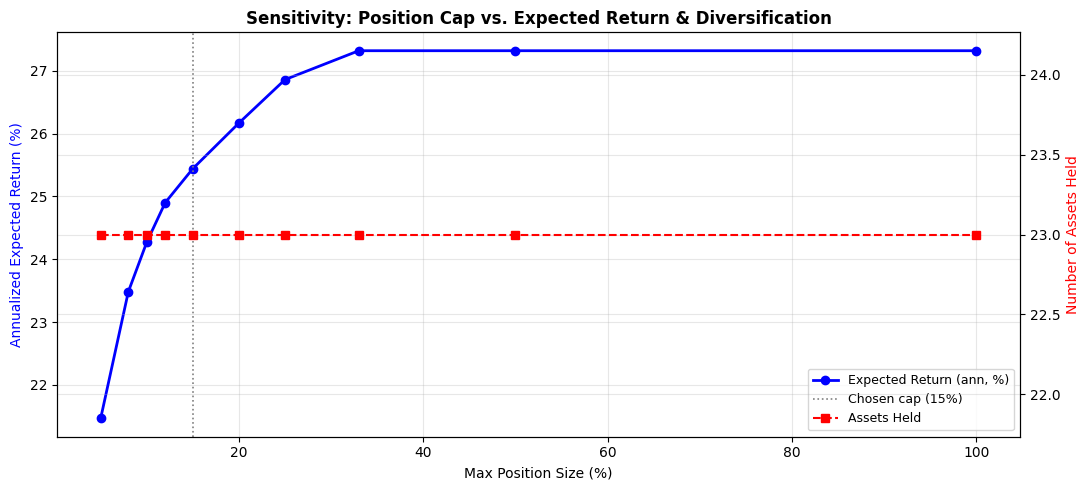

In [116]:
w_max_range = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.33, 0.50, 1.00]
sensitivity = []

for wm in w_max_range:
    r = solve_lp(
        train_returns = train_window,
        w_prev        = w_prev_init,
        tickers       = TICKERS,
        ticker_sector = TICKER_SECTOR,
        sectors       = SECTORS,
        w_max         = wm
    )
    n_held = int((r['weights'] > 0.001).sum())
    sensitivity.append({
        'w_max (%)': wm * 100,
        'Exp Return (ann, %)': round(r['exp_return'] * 12 * 100, 3),
        'Assets Held': n_held,
        'Turnover (%)': round(r['turnover'] * 100, 2)
    })

sens_df = pd.DataFrame(sensitivity)
print(sens_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(sens_df['w_max (%)'], sens_df['Exp Return (ann, %)'],
         'b-o', linewidth=2, label='Expected Return (ann, %)')
ax2.plot(sens_df['w_max (%)'], sens_df['Assets Held'],
         'r--s', linewidth=1.5, label='Assets Held')

ax1.axvline(W_MAX * 100, color='gray', linestyle=':', linewidth=1.2, label=f'Chosen cap ({W_MAX*100:.0f}%)')
ax1.set_xlabel('Max Position Size (%)')
ax1.set_ylabel('Annualized Expected Return (%)', color='b')
ax2.set_ylabel('Number of Assets Held', color='r')
ax1.set_title('Sensitivity: Position Cap vs. Expected Return & Diversification', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

#### The Return Curve: Three Distinct Regions

Region 1 (5% -> 25% cap): Steep climb. This is where the position cap is actively binding and costly. Going from 5% to 25% cap adds roughly 5.4 percentage points of expected return (21.5% -> 26.9%). Every percentage point you add to the cap meaningfully changes the solution because the optimizer is being released from a tight constraint it desparately wants to escape. 

Region 2 (25% -> 33% cap): Flattening. The curve decelerates sharply. The optimizer is getting close to its unconstrained optimum. The marginal value of relaxing the cap further is diminishing. 

Region 3 (33% -> 100% cap): Completely flat at 27.32%. The curve flatlines. This is the unconstrained optimum. The LP's natural solution with no position limits. Beyond 33%, the optimizer doesn't want to concentrate further regardless of permission. This tells us that the LP's natural maximum concentration in any single asset is around 33% for this trianing window, driven by the turnover cap rather than the position cap. 

#### Assets Held: Flat at 23 Across All Cap Levels

This is a surpising and important result. We might expect that a tighter position cap forces the optimizer to hold more assets to fill the portfolio but it stays at 23 throughout. This tells us that the set of assets with positive expected return worth holding doesn't change as we adjust the cap - only the amounts change. The 7 excluded assets (SLB, XOM, TSLA, UPS, VZ, KO, DUK) are so unattractive on a return basis that no position cap level makes them worth including. 

This is a clean finding: our LP's asset selection is driven entirely by expected return ranking, not by the cap constraint. The cap only affects how much of each selected asset to hold. 

#### The Cost of Your Chosen 15% Cap

The chosen cap of 15% delivers 25.44% expected return versus the unconstrained optimum of 27.32%. The cost of diversification is therefore: 
$$27.32 - 25.44 = 1.88 \text{    percentage points of annualized expected return}$$

This is the price we are paying, in expected return terms, for the risk protection the position cap provides. Whether that tradeoff is worth it is precisely the backtest will help answer: if the constrained portfolio outperforms out-of-sample, the constraint will have proven its value. 

#### Turnover Constraint at 50% Throughout

Every row shows 50% turnover regardless of cap level. This confirms the turnover cap, not the position cap, is the binding constraint on portfolio movement in period 1. The optimizer is always using its full rebalancing budget, just redistributing weights differently depending on how concentrated it's allowed to be. 

#### For the Paper

Three key takeaways: 
1. The cost of diversification is 1.88% annualized for the chosen 15% cap relative to an unconstrained LP - concrete, quantified tradeoff
2. The natural concentration ceiling is ~33%. The LP never wants to put more than a third of the portfolio in a single asset even when unconstrained, which is a useful bound to report.
3. Asset selection is robust to the cap. The same 23 assets are held at every constraint level, suggesting the LP's inclusion / exclusion decisions are stable and not sensitive to this parameter choice. 

### Sensitivity Analysis: Sector Cap

 Sector Cap (%)  Exp Return (ann, %)  Status
           20.0               25.101 Optimal
           25.0               25.443 Optimal
           30.0               25.443 Optimal
           35.0               25.443 Optimal
           40.0               25.443 Optimal
           50.0               25.443 Optimal
           60.0               25.443 Optimal
          100.0               25.443 Optimal


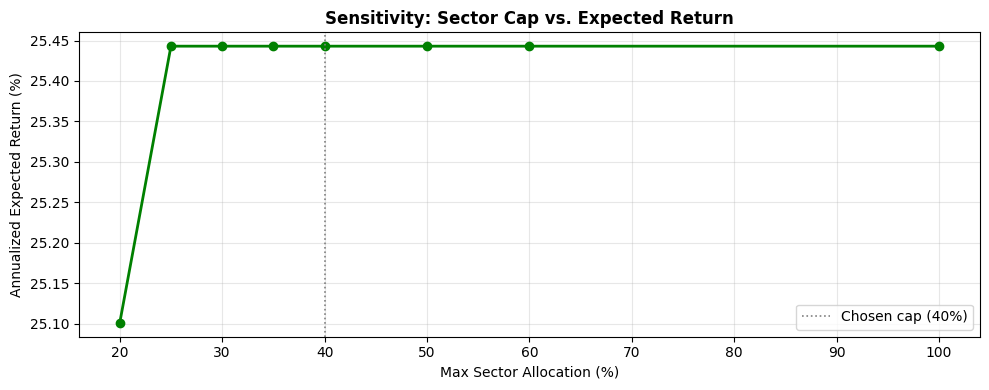

In [119]:
sector_cap_range = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 1.00]
sector_sens = []

for sc in sector_cap_range:
    r = solve_lp(
        train_returns = train_window,
        w_prev        = w_prev_init,
        tickers       = TICKERS,
        ticker_sector = TICKER_SECTOR,
        sectors       = SECTORS,
        sector_max    = sc
    )
    sector_sens.append({
        'Sector Cap (%)': sc * 100,
        'Exp Return (ann, %)': round(r['exp_return'] * 12 * 100, 3),
        'Status': r['status']
    })

sc_df = pd.DataFrame(sector_sens)
print(sc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sc_df['Sector Cap (%)'], sc_df['Exp Return (ann, %)'], 'g-o', linewidth=2)
ax.axvline(SECTOR_MAX * 100, color='gray', linestyle=':', linewidth=1.2, label=f'Chosen cap ({SECTOR_MAX*100:.0f}%)')
ax.set_xlabel('Max Sector Allocation (%)')
ax.set_ylabel('Annualized Expected Return (%)')
ax.set_title('Sensitivity: Sector Cap vs. Expected Return', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

#### The Sector Cap Flatlines Almost Immediately

The curve jumps from 25.10% to 25.44% between 20% and 25%, then is completely flat from 25% all the way to 100%. This visually confirms what the constraint diagnosis already told us: the sector cap becomes non-binding at 25% and stays non-binding forever after. Our chosen 40% cap sits well inside the flat region. 

#### The Cost of the Sector Cap is Nearly Zero

Contrast this with the position cap sensitivity: 

| Constraint | Cost of chosen cap vs. unconstrained |
| --- | --- |
| Position cap (15%) | 1.88% annualized - meaningful |
| Sector cap (40%) | 0.00% annualized - essentially free |

The sector cap costs us nothing at 40% because the position cap already prevents any sector from concentrating enough to hit 40%. We're getting sector diversification for free as a byproduct of position-level limits. This is a clean finding. 

#### The Only Costly Point: 20% Sector Cap

At 20%, the return drops to 25.10%, a cost of 0.34 percentage points. This is the only level where the sector cap actually bites, because at 20% we're concentrating IT (which naturally wants to be at 23.3%) and Consumer Discretionary (18.3% is just under the cap but IT would be cut). This tells us the effective binding threshold for the sector cap is somewhere between 20% and 25% for this training window. We would need to go below 23.3% to start affecting the IT allocation. 

#### What this Means for our Model Design

Two practical implications worth stating. First, we could tighten the sector cap from 40% to 25% at no cost to expected return, while gaining a stronger risk guardrail against future regime changes. Second, the sector cap and position cap are partially redundant constraints in this setup. The position cap is doing the heavy lifting, and the sector cap is a backstop that only matters in extreme scenarios. This redundancy is actually desirable in practice. It measn the model is robust to different types of concentration risk. 

#### Pulling the Two Sensitivity Charts Together for the Paper

The contrast between the two charts is our strongest analytical result from this workbook: 
- The position cap has a steep, nonlinear effect on expected return. It is the dominant active constraint
- The sector cap has a near-zero effect above 25%. It is a passibe safety constraint
- Togehter they create a model where one constraint optimizes, the other protects

That framing (active constraint vs. protective constraint) is a crisp way to explain our model design to a reader and sets up the walk-forward results nicely. 

### Save Outputs

In [122]:
os.makedirs('data', exist_ok=True)

# Save initial optimal weights
init_weights = pd.Series(result['weights'], index=TICKERS)
init_weights.to_csv('data/lp_weights_period0.csv', header=['weight'])

# Save the full allocation table
alloc[display_cols].to_csv('data/lp_alloc_period0.csv')

print('Saved:')
print('data/lp_weights_period0.csv - initial LP weights')
print('data/lp_alloc_period0.csv - full allocation table')
print()
print('Next: Walk-Forward Backtest')

Saved:
data/lp_weights_period0.csv - initial LP weights
data/lp_alloc_period0.csv - full allocation table

Next: Walk-Forward Backtest
